In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
tf.keras.utils.set_random_seed(12)

batch_size = 32
img_height = img_width =224

In [3]:
directory = "dataset/train"
test = "dataset/valid"

In [4]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="binary",
    #class_names=None,
    shuffle=True,
    seed=12,
    validation_split= 0.15,
    subset="training",
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 1924 files belonging to 2 classes.


Using 1636 files for training.


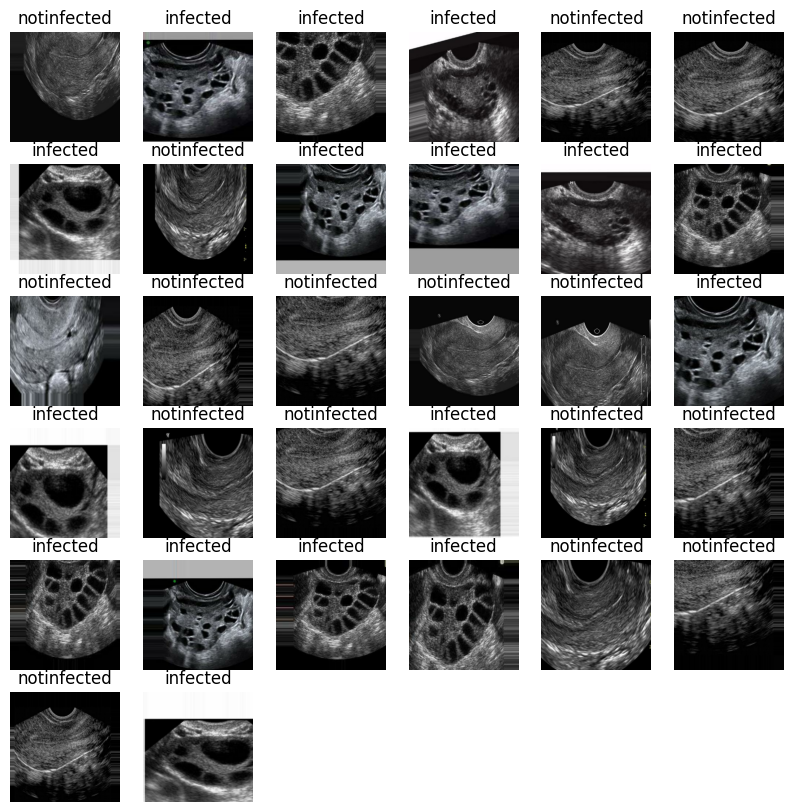

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
class_names = train_ds.class_names
for images, labels in train_ds.take(2):
    for i in range(32):
        ax = plt.subplot(6, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale = 1./255,
                             shear_range = 0.2,
                             zoom_range = 0.2,
                             #width_shift_range=0.2,
                             #height_shift_range=0.2,
                             horizontal_flip = True,
                             vertical_flip=True,
                             rotation_range=20,
                             validation_split=0.2,
                             fill_mode='nearest'
                             )
# prepare an iterators for each dataset
train_ds = datagen.flow_from_directory(directory,
                                       class_mode='categorical',
                                       classes=['infected', 'notinfected'],
                                       target_size=(224, 224),
                                       batch_size=batch_size,
                                       subset='training',
                                       seed=12)
# prepare an iterators for each dataset
val_ds = datagen.flow_from_directory( directory,
                                      class_mode='categorical',
                                      classes=['infected', 'notinfected'],
                                      target_size=(224, 224),
                                      batch_size=batch_size,
                                      subset='validation',
                                      seed=12)

Found 1540 images belonging to 2 classes.


Found 384 images belonging to 2 classes.


In [7]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test,
    seed=12,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 1932 files belonging to 2 classes.


In [8]:
model = Sequential()
 
model.add(Conv2D(12, (5,5), padding='SAME', activation='relu', input_shape=(img_height, img_width, 3)))
model.add(MaxPooling2D(pool_size=(2,2)))
#model.add(Dropout(0.1))

model.add(Conv2D(8, (5,5),padding='SAME',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
#model.add(Dropout(0.1))

model.add(Conv2D(4, (5,5),padding='SAME',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())

model.add(Dense(2,activation='softmax'))

opt=Adam(learning_rate=0.01)
model.compile(optimizer=opt, loss=BinaryCrossentropy(), metrics=['accuracy'])

In [9]:
earlyStopping = EarlyStopping(monitor="val_loss", mode="min", verbose=1,patience=15)

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    callbacks=[earlyStopping],
    batch_size=batch_size,
    verbose=1,
    epochs=20)

Epoch 1/20


 1/49 [..............................] - ETA: 2:12 - loss: 0.6911 - accuracy: 0.6250

 2/49 [>.............................] - ETA: 31s - loss: 1.0034 - accuracy: 0.6406 

 3/49 [>.............................] - ETA: 30s - loss: 0.8982 - accuracy: 0.6146

 4/49 [=>............................] - ETA: 30s - loss: 0.8460 - accuracy: 0.5703

...

46/49 [===========================>..] - ETA: 3s - loss: 0.0228 - accuracy: 0.9945

47/49 [===========================>..] - ETA: 2s - loss: 0.0223 - accuracy: 0.9946

48/49 [============================>.] - ETA: 1s - loss: 0.0219 - accuracy: 0.9947

49/49 [==============================] - ETA: 0s - loss: 0.0214 - accuracy: 0.9948

49/49 [==============================] - 64s 1s/step - loss: 0.0214 - accuracy: 0.9948 - val_loss: 0.0148 - val_accuracy: 0.9948


In [11]:
model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 conv2d (Conv2D)             (None, 224, 224, 12)      912       


 max_pooling2d (MaxPooling2  (None, 112, 112, 12)      0         


...

 dense (Dense)               (None, 2)                 6274      


Total params: 10398 (40.62 KB)


Trainable params: 10398 (40.62 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


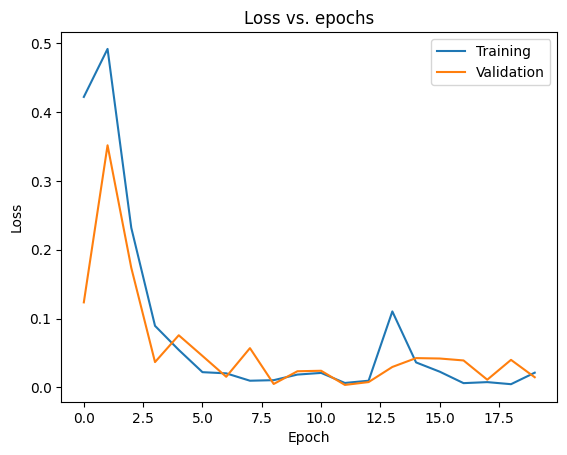

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

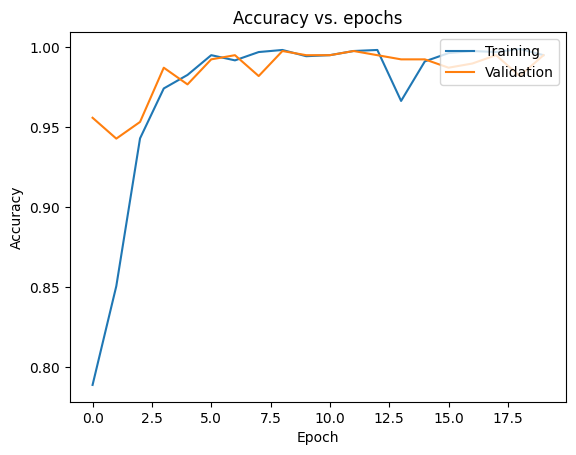

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

In [14]:
model.evaluate(val_ds)

 1/12 [=>............................] - ETA: 5s - loss: 0.0087 - accuracy: 1.0000

 2/12 [====>.........................] - ETA: 5s - loss: 0.0085 - accuracy: 1.0000

 3/12 [======>.......................] - ETA: 5s - loss: 0.0058 - accuracy: 1.0000

 4/12 [=========>....................] - ETA: 4s - loss: 0.0087 - accuracy: 1.0000

 5/12 [===========>..................] - ETA: 3s - loss: 0.0070 - accuracy: 1.0000

...

10/12 [========================>.....] - ETA: 1s - loss: 0.0163 - accuracy: 0.9969

11/12 [==========================>...] - ETA: 0s - loss: 0.0154 - accuracy: 0.9972

12/12 [==============================] - ETA: 0s - loss: 0.0345 - accuracy: 0.9948

12/12 [==============================] - 6s 536ms/step - loss: 0.0345 - accuracy: 0.9948


[0.034528326243162155, 0.9947916865348816]

In [15]:
model.save('image_model.keras')